In [2]:
"""Plot episode rewards from one or more metrics.json files.

Usage:
    python visualize_rewards.py --metrics-path runs/exp14/metrics.json
    python visualize_rewards.py --metrics-path runs/exp14/metrics.json --metrics-path runs/exp15/metrics.json
    python visualize_rewards.py --metrics-path runs/exp14/metrics.json --metrics-path runs/exp15/metrics.json \
        --labels exp14 exp15 --save-path runs/comparison.png

Requires matplotlib (pip install matplotlib) and supports optional file output.
"""

from __future__ import annotations

import argparse
import json
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt


def parse_args(argv: Sequence[str] | None = None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Visualize per-episode rewards from training metrics.")
    parser.add_argument(
        "--metrics-path",
        dest="metrics_paths",
        type=Path,
        action="append",
        help="Path to a metrics JSON file (repeat for multiple runs). Defaults to runs/exp14/metrics.json if omitted.",
    )
    parser.add_argument(
        "--save-path",
        type=Path,
        default=None,
        help="Optional path to save the generated plot as an image (e.g., PNG). If omitted, the plot is only shown.",
    )
    parser.add_argument(
        "--labels",
        nargs="+",
        default=None,
        help="Optional labels for each metrics path (must match the number of --metrics-path arguments).",
    )
    parser.add_argument(
        "--title",
        type=str,
        default="Episode Rewards",
        help="Custom title for the plot.",
    )
    args = parser.parse_args(argv)

    if not args.metrics_paths:
        args.metrics_paths = [Path("runs/exp14/metrics.json")]

    if args.labels and len(args.labels) != len(args.metrics_paths):
        parser.error("Number of labels must match number of --metrics-path entries.")

    return args


def load_metrics(path: Path) -> tuple[list[int], list[float]]:
    if not path.exists():
        raise FileNotFoundError(f"Metrics file not found: {path}")

    with path.open("r", encoding="utf-8") as fp:
        data = json.load(fp)

    episodes = []
    rewards = []
    for entry in data:
        if "episode" in entry and "reward" in entry:
            episodes.append(int(entry["episode"]))
            rewards.append(float(entry["reward"]))

    if not episodes:
        raise ValueError(f"No episode/reward pairs found in {path}")

    return episodes, rewards


def plot_rewards(series: Sequence[tuple[str, Sequence[int], Sequence[float]]], title: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, episodes, rewards in series:
        ax.plot(episodes, rewards, linewidth=1.5, label=label)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)
    if len(series) > 1:
        ax.legend()
    return fig


def main(argv: Sequence[str] | None = None) -> None:
    args = parse_args(argv)
    labels = args.labels or []

    series: list[tuple[str, list[int], list[float]]] = []
    for idx, path in enumerate(args.metrics_paths):
        episodes, rewards = load_metrics(path)
        if labels:
            label = labels[idx]
        else:
            label = path.parent.name or path.stem
        series.append((label, episodes, rewards))

    fig = plot_rewards(series, args.title)

    if args.save_path:
        args.save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(args.save_path, dpi=150, bbox_inches="tight")
        print(f"Saved reward plot to {args.save_path}")

    plt.show()

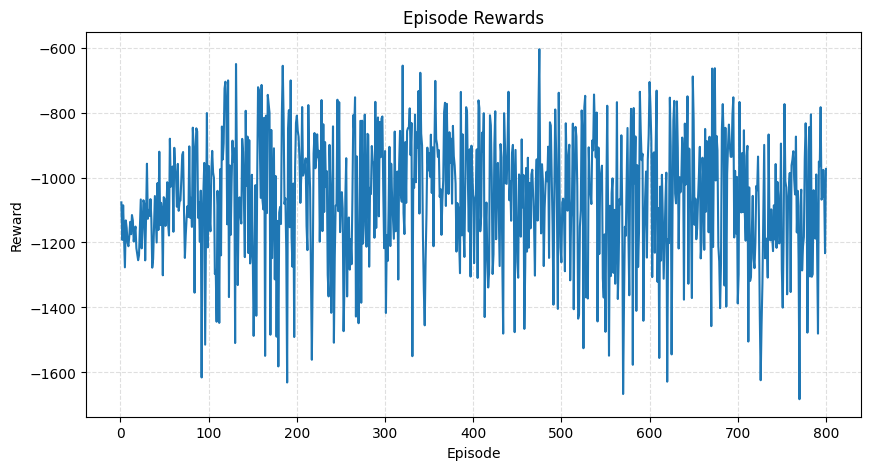

In [14]:
import shlex

main(shlex.split("--metrics-path ./exp15/metrics.json"))